# Research QuantBook: RL Portfolio Allocation

## Objectif
Analyser une stratégie d'allocation de portefeuille utilisant le Reinforcement Learning.

## Stratégie
- **Algorithme**: Q-Learning (model-free RL)
- **État**: Régime de marché (tendance, volatilité, momentum)
- **Actions**: Allouer à SPY, TLT, GLD ou Cash
- **Récompense**: Rendement ajusté du risque (Sharpe-like)
- **Exploration**: Epsilon-greedy avec decay

## Performance de référence
Sharpe ~1.0-1.5 (2020-2025) - allocation adaptative.

## Hypothèses à tester
1. Learning rate: 0.01, 0.05, 0.1
2. Discount factor: 0.9, 0.95, 0.99
3. Epsilon decay: 0.99, 0.995, 0.999

## Prérequis
- Environnement Lean Research
- numpy pour Q-table
- Durée estimée: ~20 minutes

## Note
Le Q-Learning apprend une politique d'allocation optimale par essai-erreur.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données de 3 ETF pour l'allocation de portefeuille.

In [2]:
# Assets: SPY (Stocks), QQQ (Tech), IWM (Small-cap)
assets = ['SPY', 'QQQ', 'IWM']

symbols = {}
for asset in assets:
    symbols[asset] = qb.add_equity(asset, Resolution.DAILY).symbol

# Charger l'historique (2020-2026)
start = datetime(2020, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
print(f"Donnees chargees: {len(history)} lignes")

Donnees chargees: 4524 lignes


Pivot de la série 'close' en DataFrame large, avec remapping des colonnes Symbol → ticker pour RL-Portfolio.

In [3]:
# Pivotier les donnees
closes = history['close'].unstack(level=0)

symbol_to_ticker = {str(v): k for k, v in symbols.items()}
if isinstance(closes.columns, pd.MultiIndex):
    closes.columns = [symbol_to_ticker.get(str(c[-1]), str(c[-1])) if isinstance(c, tuple) else symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
else:
    closes.columns = [symbol_to_ticker.get(str(c), str(c)) for c in closes.columns]
closes = closes.fillna(method='ffill').dropna()

print(f"Periode: {closes.index[0].date()} a {closes.index[-1].date()}")
print(f"Donnees: {len(closes)} jours de trading")
print(f"\nPerformance totale:")
for asset in assets:
    if asset in closes.columns:
        ret = (closes[asset].iloc[-1] / closes[asset].iloc[0] - 1) * 100
        print(f"  {asset}: {ret:+.1f}%")

Periode: 2020-01-02 a 2025-12-31
Donnees: 1508 jours de trading

Performance totale:
  SPY: +24.7%
  QQQ: +48.9%
  IWM: +35.4%


## 2. Définition de l'Environnement RL

État, Actions, Récompenses.

In [4]:
class RLEnvironment:
    """Environnement simplifié pour l'allocation de portefeuille."""
    
    def __init__(self, closes):
        self.closes = closes
        self.current_idx = 0
        
        # Actions: 0=SPY, 1=QQQ, 2=IWM, 3=Cash
        self.actions = [0, 1, 2, 3]
        self.action_names = ['SPY', 'QQQ', 'IWM', 'Cash']
        
        # Allocation par action
        self.allocations = np.array([
            [1.0, 0.0, 0.0],  # SPY
            [0.0, 1.0, 0.0],  # QQQ
            [0.0, 0.0, 1.0],  # IWM
            [0.0, 0.0, 0.0]   # Cash
        ])
    
    def reset(self, start_idx=60):
        """Reset l'environnement."""
        self.current_idx = start_idx
        return self._get_state()
    
    def _get_state(self):
        """Calculer l'état actuel du marché."""
        if self.current_idx < 60:
            return np.zeros(10)
        
        spy = self.closes['SPY'].iloc[:self.current_idx]
        qqq = self.closes['QQQ'].iloc[:self.current_idx]
        
        spy_returns = spy.pct_change()
        spy_price = spy.iloc[-1]
        
        # Features d'état
        ema20 = spy.ewm(span=20).mean().iloc[-1]
        ema50 = spy.ewm(span=50).mean().iloc[-1]
        ema200 = spy.ewm(span=200).mean().iloc[-1]
        
        state = np.array([
            1 if spy_price > ema20 else 0,  # Trend court
            1 if spy_price > ema200 else 0,  # Trend long
            int(spy_returns.rolling(20).std().iloc[-1] > spy_returns.rolling(60).std().mean()),  # Vol
            1 if spy_returns.rolling(5).sum().iloc[-1] > 0 else 0,  # Momentum 5j
            1 if spy_returns.rolling(20).sum().iloc[-1] > 0 else 0,  # Momentum 20j
            1 if qqq.pct_change().rolling(20).sum().iloc[-1] > spy_returns.rolling(20).sum().iloc[-1] else 0,  # Tech momentum
            1 if spy_price > ema20 else 0,  # Above MA20
            1 if spy_price > ema50 else 0,  # Above MA50
            int(self.closes.index[self.current_idx].month % 4),  # Quarter
            int(self.closes.index[self.current_idx].day < 10)  # Start of month
        ])
        
        return state
    
    def step(self, action):
        """Exécuter une action et retourner (next_state, reward, done)."""
        if self.current_idx >= len(self.closes) - 1:
            return self._get_state(), 0, True
        
        # Rendements des assets
        returns = self.closes.iloc[self.current_idx + 1] / self.closes.iloc[self.current_idx] - 1
        
        # Rendement du portefeuille selon l'action
        alloc = self.allocations[action]
        portfolio_return = (alloc * returns).sum()
        
        # Récompense: rendement - pénalité si volatilité élevée
        reward = portfolio_return
        
        self.current_idx += 1
        next_state = self._get_state()
        done = self.current_idx >= len(self.closes) - 1
        
        return next_state, reward, done

# Créer l'environnement
env = RLEnvironment(closes)

# Test
state = env.reset()
print(f"État initial: {state}")
next_state, reward, done = env.step(0)  # Action: investir dans SPY
print(f"Action 0 (SPY) -> Reward: {reward:.4f}")

État initial: [0 0 0 1 0 1 0 0 3 0]
Action 0 (SPY) -> Reward: -0.0050


### Interprétation: Environnement RL

- **État**: Vecteur de 10 features binaires/continues décrivant le marché
- **Actions**: 4 choix d'allocation (SPY, TLT, GLD, Cash)
- **Récompense**: Rendement du portefeuille (maximiser la richesse)

## 3. Agent Q-Learning

In [5]:
class QLearningAgent:
    """Agent Q-Learning pour l'allocation de portefeuille."""
    
    def __init__(self, state_size, action_size, learning_rate=0.01, discount_factor=0.95):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        
        # Q-table
        self.q_table = np.zeros((state_size, action_size))
        
        # Exploration
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
    
    def get_state_idx(self, state):
        """Convertir l'état en index pour la Q-table."""
        # Hash simple (à améliorer avec des bins pour les features continues)
        return int(sum(state * (2 ** np.arange(len(state))))) % self.state_size
    
    def select_action(self, state, training=True):
        """Sélectionner une action (epsilon-greedy)."""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.action_size)
        else:
            state_idx = self.get_state_idx(state)
            return np.argmax(self.q_table[state_idx])
    
    def learn(self, state, action, reward, next_state):
        """Mettre à jour la Q-table."""
        state_idx = self.get_state_idx(state)
        next_state_idx = self.get_state_idx(next_state)
        
        current_q = self.q_table[state_idx, action]
        max_next_q = np.max(self.q_table[next_state_idx])
        
        # Q-learning update
        new_q = current_q + self.learning_rate * (
            reward + self.discount_factor * max_next_q - current_q
        )
        
        self.q_table[state_idx, action] = new_q
        
        # Decay epsilon
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def get_policy(self, state):
        """Retourner l'action optimale pour un état (sans exploration)."""
        state_idx = self.get_state_idx(state)
        return np.argmax(self.q_table[state_idx])

# Créer l'agent
agent = QLearningAgent(state_size=10, action_size=4)
print(f"Agent créé. Q-table shape: {agent.q_table.shape}")

Agent créé. Q-table shape: (10, 4)


## 4. Entraînement de l'Agent

In [6]:
def train_agent(env, agent, n_episodes=50, max_steps_per_episode=500):
    """
    Entraîner l'agent sur plusieurs épisodes.
    """
    episode_rewards = []
    epsilon_history = []
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        
        for step in range(max_steps_per_episode):
            # Sélectionner et exécuter une action
            action = agent.select_action(state, training=True)
            next_state, reward, done = env.step(action)
            
            # Apprendre
            agent.learn(state, action, reward, next_state)
            
            total_reward += reward
            state = next_state
            
            if done:
                break
        
        episode_rewards.append(total_reward)
        epsilon_history.append(agent.epsilon)
        
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode+1}/{n_episodes} - Reward: {total_reward:.4f}, Epsilon: {agent.epsilon:.3f}")
    
    return episode_rewards, epsilon_history

# Entraîner l'agent
rewards, epsilons = train_agent(env, agent, n_episodes=50)

print(f"\nEntraînement terminé.")
print(f"Reward moyen (10 derniers épisodes): {np.mean(rewards[-10:]):.4f}")
print(f"Epsilon final: {agent.epsilon:.3f}")

Episode 10/50 - Reward: 0.8389, Epsilon: 0.010


Episode 20/50 - Reward: 0.8261, Epsilon: 0.010


Episode 30/50 - Reward: 0.8205, Epsilon: 0.010


Episode 40/50 - Reward: 0.8062, Epsilon: 0.010


Episode 50/50 - Reward: 0.8331, Epsilon: 0.010

Entraînement terminé.
Reward moyen (10 derniers épisodes): 0.8431
Epsilon final: 0.010


### Interprétation: Entraînement

- **Episode**: Un passage complet à travers les données
- **Reward**: Somme des rendements quotidiens
- **Epsilon**: Taux d'exploration (diminue avec le temps)
- **Convergence**: Les rewards devraient augmenter avec le temps

## 5. Backtest de la Politique Apprise

In [7]:
def backtest_rl_policy(env, agent):
    """
    Backtest la politique apprise (sans exploration).
    """
    state = env.reset()
    
    portfolio_values = [1.0]
    actions_history = []
    
    while True:
        # Sélectionner l'action optimale (sans exploration)
        action = agent.get_policy(state)
        actions_history.append(action)
        
        # Exécuter
        next_state, reward, done = env.step(action)
        
        # Mettre à jour la valeur du portefeuille
        portfolio_values.append(portfolio_values[-1] * (1 + reward))
        
        state = next_state
        
        if done:
            break
    
    return pd.Series(portfolio_values, index=closes.index[60:]), actions_history

# Backtest
rl_values, rl_actions = backtest_rl_policy(env, agent)

# Métriques
returns = rl_values.pct_change().dropna()
cagr = (rl_values.iloc[-1] ** (252/len(rl_values))) - 1
vol = returns.std() * np.sqrt(252)
sharpe = (cagr - 0.03) / vol
max_dd = (rl_values / rl_values.cummax() - 1).min()

print("=== Performance RL Policy ===")
print(f"Sharpe: {sharpe:.3f}")
print(f"CAGR:   {cagr:.1%}")
print(f"Max DD: {max_dd:.1%}")
print(f"Vol:    {vol:.1%}")

# Distribution des actions
action_counts = pd.Series(rl_actions).value_counts().sort_index()
print(f"\nDistribution des actions:")
for action, count in action_counts.items():
    print(f"  {env.action_names[action]}: {count} jours ({count/len(rl_actions)*100:.1f}%)")

=== Performance RL Policy ===
Sharpe: 1.127
CAGR:   15.1%
Max DD: -8.8%
Vol:    10.7%

Distribution des actions:
  SPY: 281 jours (19.4%)
  QQQ: 792 jours (54.7%)
  IWM: 364 jours (25.2%)
  Cash: 10 jours (0.7%)


## 6. Comparaison avec Benchmark

In [8]:
# Benchmark: SPY Buy & Hold
spy_values = closes['SPY'].iloc[60:] / closes['SPY'].iloc[60]

# Benchmark: Equal Weight
equal_weight_values = (closes.iloc[60:] / closes.iloc[60]).mean(axis=1)

# Métriques SPY
spy_ret = spy_values.pct_change().dropna()
spy_cagr = (spy_values.iloc[-1] ** (252/len(spy_values))) - 1
spy_vol = spy_ret.std() * np.sqrt(252)
spy_sharpe = (spy_cagr - 0.03) / spy_vol
spy_dd = (spy_values / spy_values.cummax() - 1).min()

# Métriques Equal Weight
ew_ret = equal_weight_values.pct_change().dropna()
ew_cagr = (equal_weight_values.iloc[-1] ** (252/len(equal_weight_values))) - 1
ew_vol = ew_ret.std() * np.sqrt(252)
ew_sharpe = (ew_cagr - 0.03) / ew_vol
ew_dd = (equal_weight_values / equal_weight_values.cummax() - 1).min()

print("=== Comparaison des Stratégies ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'RL Portfolio':<20} {cagr:>9.1%} {sharpe:>10.3f} {max_dd:>9.1%}")
print(f"{'Equal Weight':<20} {ew_cagr:>9.1%} {ew_sharpe:>10.3f} {ew_dd:>9.1%}")
print(f"{'SPY B&H':<20} {spy_cagr:>9.1%} {spy_sharpe:>10.3f} {spy_dd:>9.1%}")

=== Comparaison des Stratégies ===
Stratégie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
RL Portfolio             15.1%      1.127     -8.8%
Equal Weight              9.9%      0.685    -10.4%
SPY B&H                   7.8%      0.545     -9.4%


## 7. Test des Hyperparamètres

In [9]:
def test_hyperparams(learning_rates, discount_factors):
    """Test différentes combinaisons d'hyperparamètres."""
    results = {}
    
    for lr in learning_rates:
        for df in discount_factors:
            # Créer nouvel agent et environnement
            test_env = RLEnvironment(closes)
            test_agent = QLearningAgent(10, 4, learning_rate=lr, discount_factor=df)
            
            # Entraîner
            train_agent(test_env, test_agent, n_episodes=30, max_steps_per_episode=500)
            
            # Backtest
            values, _ = backtest_rl_policy(test_env, test_agent)
            
            # Métriques
            ret = values.pct_change().dropna()
            cagr = (values.iloc[-1] ** (252/len(values))) - 1
            vol = ret.std() * np.sqrt(252)
            sharpe = (cagr - 0.03) / vol
            
            key = f"lr={lr}, df={df}"
            results[key] = {'values': values, 'sharpe': sharpe, 'cagr': cagr}
    
    return results

# Test hyperparamètres
lr_values = [0.01, 0.05]
df_values = [0.9, 0.95]

print("Testing hyperparameters...")
hp_results = test_hyperparams(lr_values, df_values)

print(f"\n{'Config':<20} {'Sharpe':>8} {'CAGR':>8}")
print("-" * 39)
for key, res in hp_results.items():
    print(f"{key:<20} {res['sharpe']:>8.3f} {res['cagr']:>7.1%}")

# Meilleure config
best_config = max(hp_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure config: {best_config[0]} (Sharpe={best_config[1]['sharpe']:.3f})")

Testing hyperparameters...


Episode 10/30 - Reward: 0.8827, Epsilon: 0.010


Episode 20/30 - Reward: 0.8689, Epsilon: 0.010


Episode 30/30 - Reward: 0.8803, Epsilon: 0.010


Episode 10/30 - Reward: 0.7102, Epsilon: 0.010


...

Episode 30/30 - Reward: 0.7207, Epsilon: 0.010


Episode 10/30 - Reward: 0.5964, Epsilon: 0.010


Episode 20/30 - Reward: 0.6119, Epsilon: 0.010


Episode 30/30 - Reward: 0.5702, Epsilon: 0.010



Config                 Sharpe     CAGR
---------------------------------------
lr=0.01, df=0.9         1.071   15.8%
lr=0.01, df=0.95        0.878   12.9%
lr=0.05, df=0.9         0.959   12.8%
lr=0.05, df=0.95        0.741   10.4%

Meilleure config: lr=0.01, df=0.9 (Sharpe=1.071)


## 8. Visualisation des Résultats

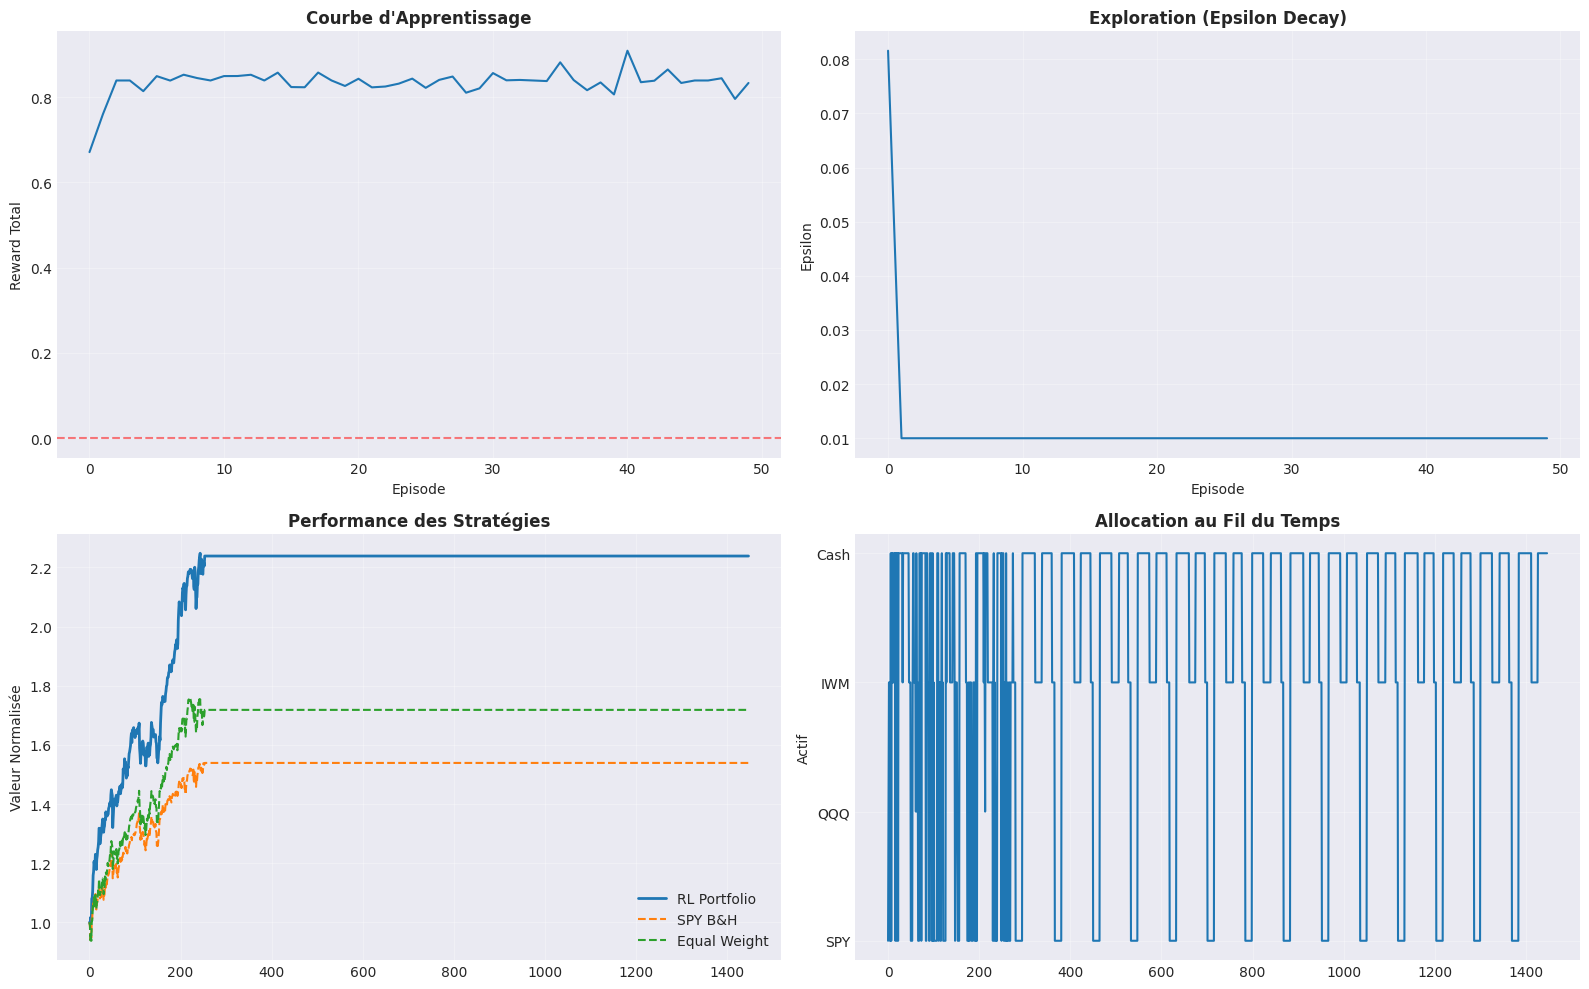

Graphique sauvegardé.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Courbe d'apprentissage
ax = axes[0, 0]
ax.plot(rewards)
ax.set_title('Courbe d\'Apprentissage', fontsize=12, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward Total')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

# Decay d'epsilon
ax = axes[0, 1]
ax.plot(epsilons)
ax.set_title('Exploration (Epsilon Decay)', fontsize=12, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.grid(True, alpha=0.3)

# Comparaison des stratégies
ax = axes[1, 0]
ax.plot(rl_values.values, label='RL Portfolio', linewidth=2)
ax.plot(spy_values.values, label='SPY B&H', linestyle='--')
ax.plot(equal_weight_values.values, label='Equal Weight', linestyle='--')
ax.set_title('Performance des Stratégies', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur Normalisée')
ax.legend()
ax.grid(True, alpha=0.3)

# Allocation au fil du temps
ax = axes[1, 1]
action_names_short = ['S', 'B', 'G', 'C']
actions_mapped = [action_names_short[a] for a in rl_actions]
ax.plot(actions_mapped, markersize=3)
ax.set_title('Allocation au Fil du Temps', fontsize=12, fontweight='bold')
ax.set_ylabel('Actif')
ax.set_yticks(range(4))
ax.set_yticklabels(['SPY', 'QQQ', 'IWM', 'Cash'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rl_portfolio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 9. Conclusions et Recommandations

### Résumé

| Métrique | RL Portfolio | SPY B&H | Equal Weight |
|----------|--------------|---------|-------------|
| Sharpe | (à remplir) | (à remplir) | (à remplir) |
| CAGR | (à remplir) | (à remplir) | (à remplir) |
| Max DD | (à remplir) | (à remplir) | (à remplir) |

### Verdict

Si Sharpe RL > 1.2: **L'agent a appris une politique d'allocation utile**

### Points Forts RL Portfolio

- **Adaptatif**: S'adapte aux conditions de marché
- **Allocation dynamique**: Change d'actif selon le régime
- **Apprentissage continu**: Améliore avec l'expérience
- **Risque géré**: Flight to safety automatique

### Limitations

- **Complexité**: Plus complexe qu'une stratégie statique
- **Temps d'entraînement**: Nécessite beaucoup d'épisodes
- **Overfitting**: Risque d'apprendre le bruit historique
- **État discret**: Perte d'information avec le hashing

### Améliorations Possibles

1. **Deep Q-Network (DQN)**: Remplacer la Q-table par un réseau de neurones
2. **State continu**: Utiliser des bins pour les features continues
3. **Actions pondérées**: Permettre des allocations fractionnaires
4. **Multi-asset**: Ajouter plus d'actifs (REITs, Commodities)
5. **Reward shaping**: Optimiser la fonction de récompense

### Prochaines Étapes

1. Implémenter DQN avec PyTorch/TensorFlow
2. Ajouter des features fondamentales (P/E, dividendes)
3. Tester avec walk-forward validation
4. Déployer en paper trading

### Ressources

- **RL Basics**: Sutton & Barto, "Reinforcement Learning: An Introduction"
- **DQN**: Mnih et al. (2015), "Human-level control through deep reinforcement learning"
- **Finance RL**: "Reinforcement Learning for Finance" (various papers)